In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import normalize, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import roc_auc_score
import fasttext
import gensim.downloader as api
import pandas as pd
from sentence_transformers import SentenceTransformer
import torch 
import gc

In [83]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = SentenceTransformer('ibm-granite/granite-embedding-30m-english')
model.to(device)

SentenceTransformer(
  (0): Transformer({'max_seq_length': 512, 'do_lower_case': False}) with Transformer model: RobertaModel 
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': True, 'pooling_mode_mean_tokens': False, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)

In [ ]:
glove = api.load("glove-wiki-gigaword-100")

In [84]:
congress_ratings = pd.read_csv(r"..\session_7_ccr\data\congress_ratings.csv")
tweet_ratings = pd.read_csv(r"..\session_7_ccr\data\document_validation_sample_w_class.csv")

In [85]:
ratings = tweet_ratings

Extract vecs with DDR + Glove

In [86]:
def average_vector(words):
    vectors = [glove[w] for w in words if w in glove]
    return np.mean(vectors, axis=0)

def document_vector(text):
    words = text.split()
    vectors = [glove[w] for w in words if w in glove]
    return np.mean(vectors, axis=0)

In [87]:
evidence_keywords = [
    "accurate",
    "exact",
    "intelligence",
    "precise",
    "search",
    "analyse",
    "examination",
    "investigate",
    "procedure",
    "show",
    "analysis",
    "examine",
    "investigation",
    "process",
    "statistics",
    "correct",
    "expert",
    "knowledge",
    "proof",
    "study",
    "correction",
    "explore",
    "lab",
    "question",
    "trial",
    "data",
    "fact",
    "learn",
    "read",
    "real",
    "dossier",
    "find",
    "logic",
    "reason",
    "true",
    "education",
    "findings",
    "logical",
    "research",
    "truth",
    "evidence",
    "information",
    "method",
    "science",
    "truthful",
    "evident",
    "inquiry",
    "pinpoint",
    "scientific"
]

intuition_keywords = [
    "advice",
    "doubt",
    "mislead",
    "suggestion",
    "belief",
    "fake",
    "mistaken",
    "suspicion",
    "believe",
    "fake news",
    "mistrust",
    "view",
    "bogus",
    "feeling",
    "opinion",
    "viewpoint",
    "common sense",
    "genuine",
    "perspective",
    "wrong",
    "deceive",
    "guess",
    "phony",
    "deception",
    "gut",
    "point of view",
    "dishonest",
    "instinct",
    "propaganda",
    "dishonesty",
    "intuition",
    "sense",
    "distrust",
    "lie",
    "suggest"
]

In [88]:
intuition_vec = average_vector(intuition_keywords)
evidence_vec = average_vector(evidence_keywords)

In [89]:
ratings_vecs = np.vstack([
    document_vector(text) 
    for text in ratings["text"]
])

Extract vecs with CCR + Granite

In [90]:
e2is_items = {
    "evidence": [
        "Evidence is more important than whether something feels true.",
        "A hunch needs to be confirmed with data.",
        "I trust the facts, not my instincts, to tell me what is true.",
        "I need to be able to justify my beliefs with evidence.",
        "I only believe people who make sure to be well-informed before saying what they think about a topic.",
        "I only believe a statement if it is based on empirical evidence.",
        "Before making a claim, people must first make sure they have acquired all the correct information."

    ],
    "intuition": [
        "I trust my gut to tell me what's true and what's not.",
        "I trust my initial feelings about the facts.",
        "My initial impressions are almost always right.",
        "I can usually feel when a claim is true or false even if I can't explain how I know.",
        "The fact that a person is genuine is enough for me to believe what he/she says.",
        "People should always say what they believe in, even if it goes against the evidence."
    ]
}

In [91]:
e2is_evi_ccr_vec = model.encode(
    e2is_items["evidence"],
    batch_size=64,
    convert_to_numpy=True
).mean(axis=0)

e2is_int_ccr_vec = model.encode(
    e2is_items["intuition"],
    batch_size=64,
    convert_to_numpy=True
).mean(axis=0)

In [92]:
ratings_sent_vecs = model.encode(
    ratings["text"],
    batch_size=64,
    convert_to_numpy=True
)

Calculating similarities: DDR + Glove vs. CCR + Granite

In [93]:
sims_keyword_ddr  = cosine_similarity(ratings_vecs, [evidence_vec, intuition_vec])
standardized_keyword_ddr  = StandardScaler().fit_transform(sims_keyword_ddr)

ratings["keyword_ddr_evi"] = sims_keyword_ddr[:, 0]
ratings["keyword_ddr_int"] = sims_keyword_ddr[:, 1]
ratings["keyword_ddr_score"] = standardized_keyword_ddr[:, 0] - standardized_keyword_ddr[:, 1]

In [94]:
ratings_sent_vecs = normalize(ratings_sent_vecs)
e2is_evi_ccr_vec = normalize(e2is_evi_ccr_vec.reshape(1, -1))
e2is_int_ccr_vec = normalize(e2is_int_ccr_vec.reshape(1, -1))

sims_e2is_ccr  = cosine_similarity(
    ratings_sent_vecs,
    np.vstack([e2is_evi_ccr_vec, e2is_int_ccr_vec])
)

standardized_e2is_ccr  = StandardScaler().fit_transform(sims_e2is_ccr )

ratings["e2is_ccr_evi"] = sims_e2is_ccr [:, 0]
ratings["e2is_ccr_int"] = sims_e2is_ccr [:, 1]
ratings["e2is_ccr_score"] = standardized_e2is_ccr [:, 0] - standardized_e2is_ccr [:, 1]

In [95]:
auc_ddr = roc_auc_score(ratings["class"], ratings["keyword_ddr_score"])
auc_ccr = roc_auc_score(ratings["class"], ratings["e2is_ccr_score"])

print("DDR AUC:", auc_ddr)
print("CCR AUC:", auc_ccr)

DDR AUC: 0.9564732142857143
CCR AUC: 0.8325892857142857


How would DDR of questionnaires behave?

In [99]:
e2is_int_ddr_vec = np.mean([document_vector(s) for s in e2is_items["intuition"]], axis=0) 
e2is_evi_ddr_vec = np.mean([document_vector(s) for s in e2is_items["evidence"]], axis=0) 

In [100]:
sims_e2is_ddr  = cosine_similarity(ratings_vecs, [e2is_evi_ddr_vec, e2is_int_ddr_vec])
standardized_e2is_ddr  = StandardScaler().fit_transform(sims_e2is_ddr )

ratings["e2is_ddr_evi"] = sims_e2is_ddr[:, 0]
ratings["e2is_ddr_int"] = sims_e2is_ddr[:, 1]
ratings["e2is_ddr_score"] = standardized_e2is_ddr[:, 0] - standardized_e2is_ddr[:, 1]

In [101]:
auc_ddr = roc_auc_score(ratings["class"], ratings["e2is_ddr_score"])
auc_ccr = roc_auc_score(ratings["class"], ratings["e2is_ccr_score"])

print("DDR AUC:", auc_ddr)
print("CCR AUC:", auc_ccr)

DDR AUC: 0.7555803571428572
CCR AUC: 0.8325892857142857


How would CCR of dictionary behave?

In [96]:
evidence_ccr_vec = model.encode(evidence_keywords).mean(axis=0)
intuition_ccr_vec = model.encode(intuition_keywords).mean(axis=0)

In [97]:
keyword_evi_ccr_vec = normalize(model.encode(evidence_keywords, convert_to_numpy=True).mean(axis=0).reshape(1, -1))
keyword_int_ccr_vec = normalize(model.encode(intuition_keywords, convert_to_numpy=True).mean(axis=0).reshape(1, -1))

sims_keyword_ccr  = cosine_similarity(
    ratings_sent_vecs,
    np.vstack([keyword_evi_ccr_vec, keyword_int_ccr_vec])
)

standardized_keyword_ccr  = StandardScaler().fit_transform(sims_keyword_ccr)

ratings["keyword_ccr_evi"] = sims_keyword_ccr[:, 0]
ratings["keyword_ccr_int"] = sims_keyword_ccr[:, 1]
ratings["keyword_ccr_score"] = standardized_keyword_ccr[:, 0] - standardized_keyword_ccr[:, 1]

In [98]:
auc_ddr = roc_auc_score(ratings["class"], ratings["keyword_ddr_score"])
auc_ccr = roc_auc_score(ratings["class"], ratings["keyword_ccr_score"])

print("DDR AUC:", auc_ddr)
print("CCR AUC:", auc_ccr)

DDR AUC: 0.9564732142857143
CCR AUC: 0.8381696428571429


In [102]:
results = []

baseline_auc = roc_auc_score(ratings["class"], ratings["e2is_ccr_score"])

print("Baseline AUC:", baseline_auc)

# Leave-one-out loop
for group in ["evidence", "intuition"]:
    items = e2is_items[group]

    for i in range(len(items)):
        
        reduced_items = items[:i] + items[i+1:]

        if group == "evidence":
            evi_vec = model.encode(reduced_items, convert_to_numpy=True).mean(axis=0)
            int_vec = e2is_int_ccr_vec
        else:
            evi_vec = e2is_evi_ccr_vec
            int_vec = model.encode(reduced_items, convert_to_numpy=True).mean(axis=0)

        anchor = evi_vec - int_vec

        scores = cosine_similarity(
            ratings_sent_vecs,
            anchor.reshape(1, -1)
        ).flatten()

        auc = roc_auc_score(ratings["class"], scores)

        results.append({
            "group": group,
            "removed_item": items[i],
            "auc": auc,
            "delta_auc": auc - baseline_auc
        })


results_df = pd.DataFrame(results).sort_values("auc", ascending=False)

print(results_df)

Baseline AUC: 0.8325892857142857
        group                                       removed_item       auc  \
9   intuition    My initial impressions are almost always right.  0.897321   
5    evidence  I only believe a statement if it is based on e...  0.893973   
10  intuition  I can usually feel when a claim is true or fal...  0.891741   
4    evidence  I only believe people who make sure to be well...  0.890625   
7   intuition  I trust my gut to tell me what's true and what...  0.886161   
0    evidence  Evidence is more important than whether someth...  0.885045   
2    evidence  I trust the facts, not my instincts, to tell m...  0.879464   
3    evidence  I need to be able to justify my beliefs with e...  0.875000   
1    evidence           A hunch needs to be confirmed with data.  0.873884   
12  intuition  People should always say what they believe in,...  0.872768   
8   intuition       I trust my initial feelings about the facts.  0.872768   
11  intuition  The fact that a 

What is more important: model vs items

In [103]:
epistemic_items = {
    "evidence": [
        "Evidence is more important than whether something feels true.",
        "A hunch needs to be confirmed with data.",
        "I trust the facts, not my instincts, to tell me what is true.",
        "I need to be able to justify my beliefs with evidence."
    ],
    "intuition": [
        "I trust my gut to tell me what's true and what's not.",
        "I trust my initial feelings about the facts.",
        "My initial impressions are almost always right.",
        "I can usually feel when a claim is true or false even if I can't explain how I know.",
        "Scientific conclusions are shaped by politics.",
        "Facts depend on their political context.",
        "What counts as truth is defined by power.",
        "Facts are dictated by those in power."
    ]
}

item_versions = {
    "curated":    e2is_items,
    "original": epistemic_items,
}

In [104]:
model_names = {
    "granite":     "ibm-granite/granite-embedding-107m-multilingual",
    "paraphrase":  "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    "allMini":       "sentence-transformers/all-MiniLM-L6-v2",
}

device = "cuda" if torch.cuda.is_available() else "cpu"

In [105]:
results = {} 

for model_key, model_path in model_names.items():
    print(f"\n>>> Loading {model_key}")
    model = SentenceTransformer(model_path)
    model.to(device)

    doc_vecs = normalize(model.encode(
        list(ratings["text"]),
        batch_size=64,
        convert_to_numpy=True,
        show_progress_bar=True
    ))

    for items_key, items in item_versions.items():
        print(f"  · {model_key} + {items_key}")

        evi_vec = normalize(model.encode(
            items["evidence"], convert_to_numpy=True
        ).mean(axis=0).reshape(1, -1))

        int_vec = normalize(model.encode(
            items["intuition"], convert_to_numpy=True
        ).mean(axis=0).reshape(1, -1))

        sims = cosine_similarity(doc_vecs, np.vstack([evi_vec, int_vec]))
        std  = StandardScaler().fit_transform(sims)
        score = std[:, 0] - std[:, 1]

        auc = roc_auc_score(ratings["class"], score)
        results[(model_key, items_key)] = auc
        print(f"    AUC: {auc:.4f}")

    del model
    torch.cuda.empty_cache()
    gc.collect()


>>> Loading granite


Batches: 100%|██████████| 1/1 [00:01<00:00,  1.53s/it]


  · granite + curated
    AUC: 0.8147
  · granite + original
    AUC: 0.6975

>>> Loading paraphrase


Batches: 100%|██████████| 1/1 [00:03<00:00,  3.09s/it]


  · paraphrase + curated
    AUC: 0.9074
  · paraphrase + original
    AUC: 0.8471

>>> Loading allMini


Batches: 100%|██████████| 1/1 [00:01<00:00,  1.75s/it]


  · allMini + curated
    AUC: 0.9252
  · allMini + original
    AUC: 0.7254


Should we translate the items?

In [106]:
e2is_items_pt = {
    "evidence": [
        "Evidências são mais importantes do que se algo parece verdadeiro.",
        "Um palpite precisa ser confirmado com dados.",
        "Eu confio nos fatos, não nos meus instintos, para saber o que é verdadeiro.",
        "Eu preciso ser capaz de justificar minhas crenças com evidências.",
        "Eu só acredito em pessoas que se certificam de estar bem informadas antes de dizer o que pensam sobre um assunto.",
        "Eu só acredito em uma afirmação se ela for baseada em evidências empíricas.",
        "Antes de fazer uma afirmação, as pessoas devem primeiro se certificar de que adquiriram todas as informações corretas."
    ],
    "intuition": [
        "Eu confio no meu instinto para me dizer o que é verdadeiro e o que não é.",
        "Eu confio nas minhas impressões iniciais sobre os fatos.",
        "Minhas impressões iniciais estão quase sempre certas.",
        "Geralmente consigo sentir quando uma afirmação é verdadeira ou falsa, mesmo que não consiga explicar como sei.",
        "O fato de uma pessoa ser genuína é suficiente para eu acreditar no que ela diz.",
        "As pessoas devem sempre dizer no que acreditam, mesmo que vá contra as evidências."
    ]
}

In [107]:
try:
    del model
except NameError:
    pass

torch.cuda.empty_cache()
gc.collect()

model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
model.to(device)

SentenceTransformer(
  (0): Transformer({'max_seq_length': 128, 'do_lower_case': False}) with Transformer model: BertModel 
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
)

In [108]:
e2is_evi_ccr_vec_pt = model.encode(
    e2is_items_pt["evidence"],
    batch_size=64,
    convert_to_numpy=True
).mean(axis=0)

e2is_int_ccr_vec_pt = model.encode(
    e2is_items_pt["intuition"],
    batch_size=64,
    convert_to_numpy=True
).mean(axis=0)

e2is_evi_ccr_vec_en = model.encode(
    e2is_items["evidence"],
    batch_size=64,
    convert_to_numpy=True
).mean(axis=0)

e2is_int_ccr_vec_en = model.encode(
    e2is_items["intuition"],
    batch_size=64,
    convert_to_numpy=True
).mean(axis=0)

In [109]:
brpolicorpus = pd.read_parquet("../session_6_ddr/data/BrPoliCorpus_Floor.parquet")
brpolisample = brpolicorpus.sample(n = 500, random_state=42).reset_index(drop=True)
brpolicorpus_vecs = model.encode(
    brpolisample["Discurso"],
    batch_size=64,
    convert_to_numpy=True,
    show_progress_bar=True
)

Batches: 100%|██████████| 8/8 [00:31<00:00,  3.96s/it]


In [110]:
brpolicorpus_vecs = normalize(brpolicorpus_vecs)

e2is_evi_ccr_vec_pt = normalize(e2is_evi_ccr_vec_pt.reshape(1, -1))
e2is_int_ccr_vec_pt = normalize(e2is_int_ccr_vec_pt.reshape(1, -1))
e2is_evi_ccr_vec_en = normalize(e2is_evi_ccr_vec_en.reshape(1, -1))
e2is_int_ccr_vec_en = normalize(e2is_int_ccr_vec_en.reshape(1, -1))

sims_brpolicorpus  = cosine_similarity(
    brpolicorpus_vecs,
    np.vstack([e2is_evi_ccr_vec_pt, e2is_int_ccr_vec_pt, e2is_evi_ccr_vec_en, e2is_int_ccr_vec_en])
)

standardized_brpolicorpus  = StandardScaler().fit_transform(sims_brpolicorpus)

brpolisample["e2is_ccr_evi_pt"] = sims_brpolicorpus [:, 0]
brpolisample["e2is_ccr_int_pt"] = sims_brpolicorpus [:, 1]
brpolisample["e2is_ccr_score_pt"] = standardized_brpolicorpus [:, 0] - standardized_brpolicorpus [:, 1]
brpolisample["e2is_ccr_evi_en"] = sims_brpolicorpus [:, 2]
brpolisample["e2is_ccr_int_en"] = sims_brpolicorpus [:, 3]
brpolisample["e2is_ccr_score_en"] = standardized_brpolicorpus [:, 2] - standardized_brpolicorpus [:, 3]

                   e2is_ccr_evi_pt  e2is_ccr_int_pt  e2is_ccr_score_pt
e2is_ccr_evi_en           0.988383         0.834101           0.285162
e2is_ccr_int_en           0.807564         0.971125          -0.302313
e2is_ccr_score_en         0.287812        -0.218101           0.935089


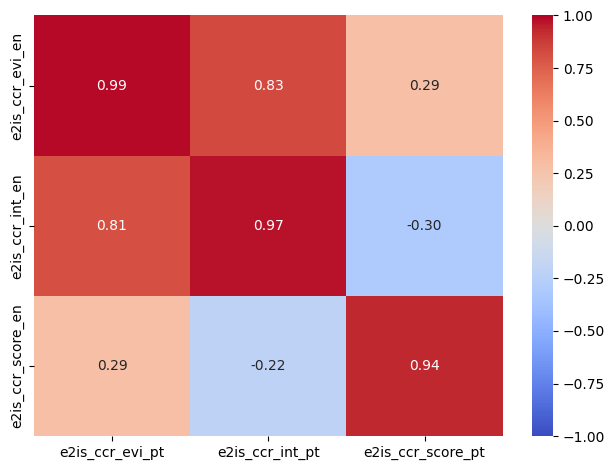

In [111]:
en_cols = ["e2is_ccr_evi_en", "e2is_ccr_int_en", "e2is_ccr_score_en"]
pt_cols = ["e2is_ccr_evi_pt", "e2is_ccr_int_pt", "e2is_ccr_score_pt"]

corr_cross = brpolisample[en_cols + pt_cols].corr()
corr_cross = corr_cross.loc[en_cols, pt_cols]

print(corr_cross) 

sns.heatmap(corr_cross, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.tight_layout()
plt.show()

Anchoring vectors

In [112]:
vec_uncle = glove["uncle"]
vec_woman = glove["woman"]
vec_man = glove["man"]
vec_aunt = glove["aunt"]

target_vec = vec_uncle - vec_man + vec_woman

cosine_similarity(
    target_vec.reshape(1, -1),
    vec_aunt.reshape(1, -1)
)[0][0]

np.float32(0.82757986)

In [113]:
glove.most_similar(
    positive=["uncle", "woman"],
    negative=["man"]
)

[('aunt', 0.8368030190467834),
 ('daughter', 0.8227198123931885),
 ('niece', 0.8220989108085632),
 ('grandmother', 0.8220454454421997),
 ('mother', 0.8078984022140503),
 ('wife', 0.7898010015487671),
 ('cousin', 0.7828285098075867),
 ('granddaughter', 0.7685597538948059),
 ('father', 0.7636010050773621),
 ('husband', 0.7516083717346191)]

In [ ]:
gender_axis = glove["woman"] - glove["man"]

words = ["doctor", "nurse", "engineer", "teacher", "director"]

for word in words:
    vec = glove[word]
    bias = np.dot(vec, gender_axis)
    print(f"{word:12} {bias:.4f}")

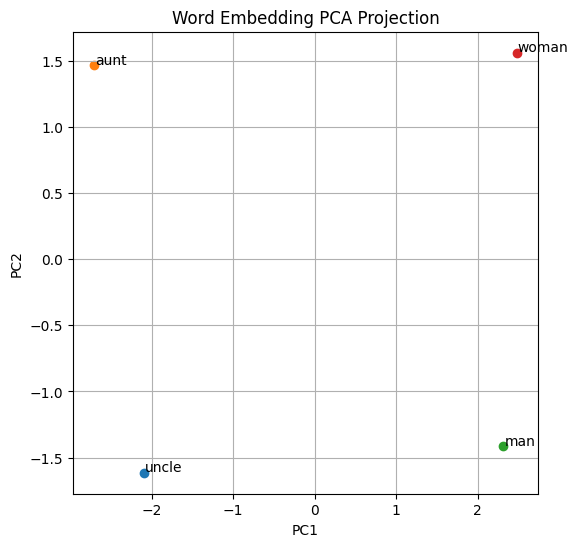

In [114]:
words = ["uncle", "aunt", "man", "woman"]

# get vectors
vectors = np.array([glove[w] for w in words])

# PCA to 2D
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)

# plot
plt.figure(figsize=(6,6))

for i, word in enumerate(words):
    x, y = vectors_2d[i]
    plt.scatter(x, y)
    plt.text(x + 0.01, y + 0.01, word)

plt.title("Word Embedding PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid()

plt.show()

In [115]:
try:
    del model
except NameError:
    pass

torch.cuda.empty_cache()
gc.collect()

model = SentenceTransformer('ibm-granite/granite-embedding-30m-english')
model.to(device)

vec_uncle = model.encode("uncle")
vec_woman = model.encode("woman")
vec_man = model.encode("man")
vec_aunt = model.encode("aunt")

target_vec = vec_uncle - vec_man + vec_woman

sim = cosine_similarity(
    target_vec.reshape(1, -1),
    vec_aunt.reshape(1, -1)
)[0][0]

print(sim)

0.5706923


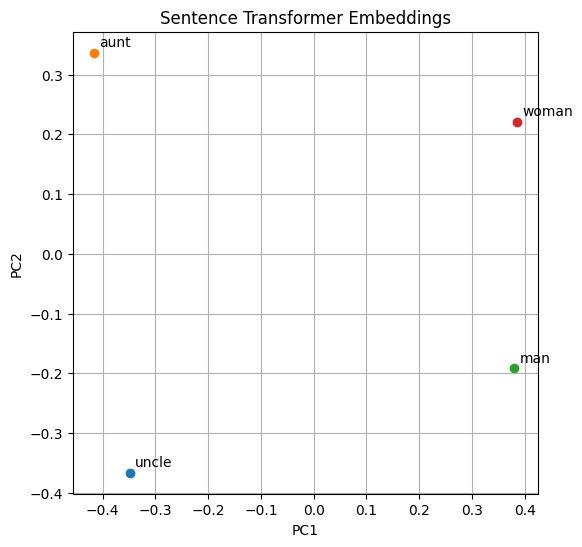

In [116]:
words = ["uncle", "aunt", "man", "woman"]

vectors = np.array([
    model.encode(w) for w in words
])

# PCA
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)

plt.figure(figsize=(6,6))

for i, word in enumerate(words):
    x, y = vectors_2d[i]
    plt.scatter(x, y)
    plt.text(x + 0.01, y + 0.01, word)

plt.title("Sentence Transformer Embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid()

plt.show()

In [117]:
words = ["happiness", "sadness", "grief", "carpet"]

vec_happy = glove["happiness"]

for word in words:
    vec = glove[word]
    sim = cosine_similarity(
        vec.reshape(1, -1),
        vec_happy.reshape(1, -1)
    )[0][0]
    
    print(f"{word:12} {sim:.4f}")

happiness    1.0000
sadness      0.6159
grief        0.5724
carpet       0.0621


In [118]:
direction = glove["happiness"] - glove["sadness"]

for word in words:
    vec = glove[word]
    sim = cosine_similarity(
        vec.reshape(1, -1),
        direction.reshape(1, -1)
    )[0][0]

    print(f"{word:12} {sim:.4f}")

for word in words:
    vec = glove[word]
    sim = np.dot(vec, direction)

    print(f"{word:12} {sim:.4f}")

for word in words:
    vec = glove[word]
    proj = (vec - glove["sadness"]) @ direction
    score = proj / np.sum(direction**2)
    print(f"{word:12} {score:.4f}")

happiness    0.3308
sadness      -0.5397
grief        -0.4296
carpet       -0.0576
happiness    7.8052
sadness      -14.2737
grief        -10.9875
carpet       -1.3712
happiness    1.0000
sadness      0.0000
grief        0.1488
carpet       0.5844


Anchored DDR

In [ ]:
ft = fasttext.load_model(r'..\session_5_embs\cc.pt.300.bin')
brpoli_doc_vecs = np.load(r"..\session_6_ddr\data\brpoli_doc_vecs.npy")

def average_vector_ft(words):
    vectors = [ft.get_word_vector(w) for w in words]
    return np.mean(vectors, axis=0)

def document_vector_ft(text):
    words = text.split()
    vectors = [ft.get_word_vector(w) for w in words]
    return np.mean(vectors, axis=0)

In [ ]:
fact_speaking = [
    "de fato",
    "analisar",
    "avaliar",
    "correto",
    "correção",
    "determinar",
    "avaliar",
    "evidência",
    "examinar",
    "exploração",
    "fato",
    "informação",
    "inspecionar",
    "investigar",
    "observar",
    "prova",
    "provar",
    "questão",
    "questionário",
    "real",
    "realidade",
    "retificar",
    "pesquisa",
    "revisar",
    "amostra",
    "ciência",
    "escrutinar",
    "buscar",
    "especificar",
    "supervisionar",
    "testar",
    "rastrear",
    "monitorar",
    "teste",
    "verdade",
    "validar",
    "verificar"
]

belief_speaking = [
    "basicamente",
    "acreditar",
    "afirmar",
    "confiar",
    "considerar",
    "contemplar",
    "contenda",
    "vislumbrar",
    "sentir",
    "francamente",
    "genuinamente",
    "achar",
    "insinuar",
    "julgar",
    "parecer",
    "óbvio",
    "obviamente",
    "claro",
    "opinião",
    "claramente",
    "ponderar",
    "posição",
    "presumir",
    "provavelmente",
    "parecer",
    "sensação",
    "sentimento",
    "sinal",
    "sugerir",
    "sugestão",
    "supor",
    "certamente",
    "pensar",
    "confiar",
    "tentar",
    "visão",
    "praticamente"
]

In [ ]:
belief_vec = average_vector_ft(belief_speaking)
fact_vec = average_vector_ft(fact_speaking)

fact_vec_n = fact_vec / np.linalg.norm(fact_vec)
belief_vec_n = belief_vec / np.linalg.norm(belief_vec)
anchored_ddr = fact_vec_n - belief_vec_n

brpoli_doc_vecs_n = normalize(brpoli_doc_vecs)

sims_poles = cosine_similarity(brpoli_doc_vecs_n, [fact_vec_n, belief_vec_n])
brpolicorpus["ddr_fact"]   = sims_poles[:, 0]
brpolicorpus["ddr_belief"] = sims_poles[:, 1]

brpolicorpus["ddr_anchored"] = brpoli_doc_vecs_n @ anchored_ddr

std = StandardScaler().fit_transform(sims_poles)
brpolicorpus["ddr_score"] = std[:, 0] - std[:, 1]

In [ ]:
cols = ["ddr_fact", "ddr_belief", "ddr_score", "ddr_anchored"]

print(brpolicorpus[cols].corr())

r, p = stats.pearsonr(brpolicorpus["ddr_score"], brpolicorpus["ddr_anchored"])
print(f"ddr_score vs ddr_anchored: r={r:.3f}, p={p:.4f}")

r, p = stats.pearsonr(brpolicorpus["ddr_fact"], brpolicorpus["ddr_belief"])
print(f"fact vs belief correlation: r={r:.3f}, p={p:.4f}")

In [ ]:
brpolicorpus["Data"] = pd.to_datetime(brpolicorpus["Data"], dayfirst=True)
brpolicorpus["era"] = pd.cut(
    brpolicorpus["Data"],
    bins=pd.to_datetime([
        "1995-01-01", 
        "2003-01-01", 
        "2011-01-01", 
        "2016-09-01", 
        "2019-01-01", 
        "2023-01-01",
        "2026-01-01" 
    ]),
    labels=[
        "FHC",
        "Lula I-II",
        "Dilma",
        "Temer",
        "Bolsonaro",
        "Lula III"
    ]
)

daily = (brpolicorpus
         .groupby("Data")["ddr_anchored"]
         .mean()
         .reset_index()
         .sort_values("Data"))

daily["ddr_rolling"] = daily["ddr_anchored"].rolling(window=30, min_periods=10).mean()

era_bounds = {
    "FHC":        ("1995-01-01", "2003-01-01", "#d9d9d9"),
    "Lula I-II":  ("2003-01-01", "2011-01-01", "#fdbf6f"),
    "Dilma":      ("2011-01-01", "2016-09-01", "#fb9a99"),
    "Temer":      ("2016-09-01", "2019-01-01", "#a6cee3"),
    "Bolsonaro":  ("2019-01-01", "2023-01-01", "#b2df8a"),
    "Lula III":   ("2023-01-01", None, "#ff7f00"),
}

events = {
    "Lava Jato": "2014-03-17",
    "Truck drivers' strike": "2018-05-21",
    "COVID (first case)": "2020-02-26",
    "STF annuls Lula convictions": "2021-03-08",
    "Jan 8 attacks": "2023-01-08",
    "Global financial crisis": "2008-09-15",
    "Mensalão scandal": "2005-06-06",
    "Cunha suspended": "2016-05-05",
}


# line plot
fig, ax = plt.subplots(figsize=(15, 7))
ax.plot(daily["Data"], daily["ddr_rolling"], color="steelblue", linewidth=1.5)

for label, date in events.items():
    ax.axvline(
        pd.Timestamp(date),
        color="grey",
        linestyle="--",
        alpha=0.5,
        linewidth=0.8
    )
    ax.text(
        pd.Timestamp(date),
        ax.get_ylim()[1],
        label,
        rotation=90,
        va="top",
        fontsize=10,
        color="black"
    )

data_start = daily["Data"].min()
data_end = daily["Data"].max()

seen = set()
for era, (start, end, color) in era_bounds.items():
    start = max(pd.Timestamp(start), data_start)
    end = pd.Timestamp(end) if end else data_end
    end = min(end, data_end)

    label = era if era not in seen else None
    ax.axvspan(start, end, alpha=0.25, color=color, label=label)
    seen.add(era)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel("DDR score (rolling mean)")
ax.set_title("Epistemic style in Brazilian floor speeches over time")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

Anchored CCR

In [119]:
anchored_e2is = e2is_evi_ccr_vec - e2is_int_ccr_vec

# ratings["ccr_anchored"] = cosine_similarity(
#     ratings_sent_vecs,
#     anchored.reshape(1, -1)
# ).flatten()

ratings["ccr_anchored"] = np.dot(ratings_sent_vecs, anchored_e2is.flatten())

In [120]:
auc_ccr = roc_auc_score(ratings["class"], ratings["e2is_ccr_score"])
auc_ccr_anc = roc_auc_score(ratings["class"], ratings["ccr_anchored"])

print("CCR AUC:", auc_ccr)
print("Anchored CCR AUC:", auc_ccr_anc)

CCR AUC: 0.8325892857142857
Anchored CCR AUC: 0.8850446428571428


In [123]:
attari_items = {
    "positive": {
        "cognitive": [
            "AI will make this world a better place.",
            "AI offers solutions to many world problems."
        ],
        "affective": [
            "I look forward to future AI developments.",
            "When I think about AI, I have mostly positive feelings."
        ],
        "behavioral": [
            "I want to use technologies that rely on AI.",
            "I would rather choose a technology with AI than one without it."
        ]
    },
    "negative": {
        "cognitive": [
            "AI has more disadvantages than advantages.",
            "AI creates problems rather than solving them."
        ],
        "affective": [
            "I have strong negative emotions about AI.",
            "I am afraid of AI."
        ],
        "behavioral": [
            "I prefer technologies that do not feature AI.",
            "I would rather avoid technologies that are based on AI."
        ]
    }
}

In [124]:
test = pd.read_csv("test.csv")

In [125]:
try:
    del model
except NameError:
    pass

torch.cuda.empty_cache()
gc.collect()

model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
model.to(device)

SentenceTransformer(
  (0): Transformer({'max_seq_length': 128, 'do_lower_case': False}) with Transformer model: BertModel 
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
)

In [126]:
attari_pos_ccr_vec = model.encode(
    [s for v in attari_items["positive"].values() for s in v],
    batch_size=64,
    convert_to_numpy=True
).mean(axis=0)

attari_neg_ccr_vec = model.encode(
    [s for v in attari_items["negative"].values() for s in v],
    batch_size=64,
    convert_to_numpy=True
).mean(axis=0)

In [127]:
test_sent_vecs = model.encode(
    test["Answer"],
    batch_size=64,
    convert_to_numpy=True
)

In [128]:
test_sent_vecs = normalize(test_sent_vecs)
attari_pos_ccr_vec = normalize(attari_pos_ccr_vec.reshape(1, -1))
attari_neg_ccr_vec = normalize(attari_neg_ccr_vec.reshape(1, -1))

anchored_attari = attari_pos_ccr_vec.flatten() - attari_neg_ccr_vec.flatten()

# ratings["ccr_anchored"] = cosine_similarity(
#     ratings_sent_vecs,
#     anchored.reshape(1, -1)
# ).flatten()

proj = (test_sent_vecs - attari_neg_ccr_vec) @ anchored_attari
test["ccr_anchored"] = proj / np.sum(anchored_attari**2)

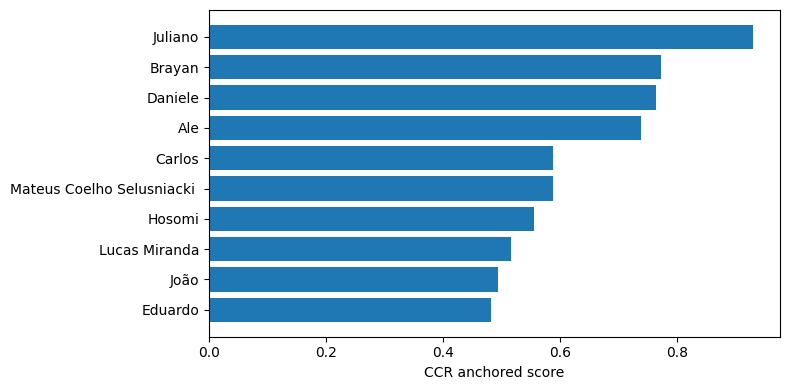

In [130]:
test_sorted = test.sort_values("ccr_anchored")

fig, ax = plt.subplots(figsize=(8, len(test_sorted) * 0.4))
ax.barh(test_sorted["Name"], test_sorted["ccr_anchored"])
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("CCR anchored score")
plt.tight_layout()
plt.show()

In [131]:
test["Answer"].to_list()

['É uma técnica de programação que cria ferramentas que resolvem problemas tentando imitar oque um ser humano faria para resolver esses problemas. É útil para ganhar tempo em diversas tarefas e pode abrir portas para resolver muitos problemas que não seria possível de resolver em tempo habil sem essas ferramentas.',
 'It is a tool that will help with some of our daily tasks; It helps to automate boring tasks but still require a human in the loop for safety',
 'Its a very powerful and helpful tool that can help in a big variety of activities. But it is not a silver bullet than can solve any problem, specially without human supervision (a recipe for disaster).',
 "It's a great tool to help us in a world full of information. It helps humans to find things easier and feel less overwhelmed by the lot of information that we receive daily.",
 'Artificial intelligence is a field that has emerged to revolutionize the way we live. It’s not only about the integrations we can create, but also abou

In [132]:
dimensions = ["cognitive", "affective", "behavioral"]

for dim in dimensions:
    pos_vec = normalize(
        model.encode(attari_items["positive"][dim], batch_size=64, convert_to_numpy=True)
        .mean(axis=0).reshape(1, -1)
    ).flatten()

    neg_vec = normalize(
        model.encode(attari_items["negative"][dim], batch_size=64, convert_to_numpy=True)
        .mean(axis=0).reshape(1, -1)
    ).flatten()

    direction = pos_vec - neg_vec
    proj = (test_sent_vecs - neg_vec) @ direction
    test[f"ccr_{dim}"] = proj / np.sum(direction**2)

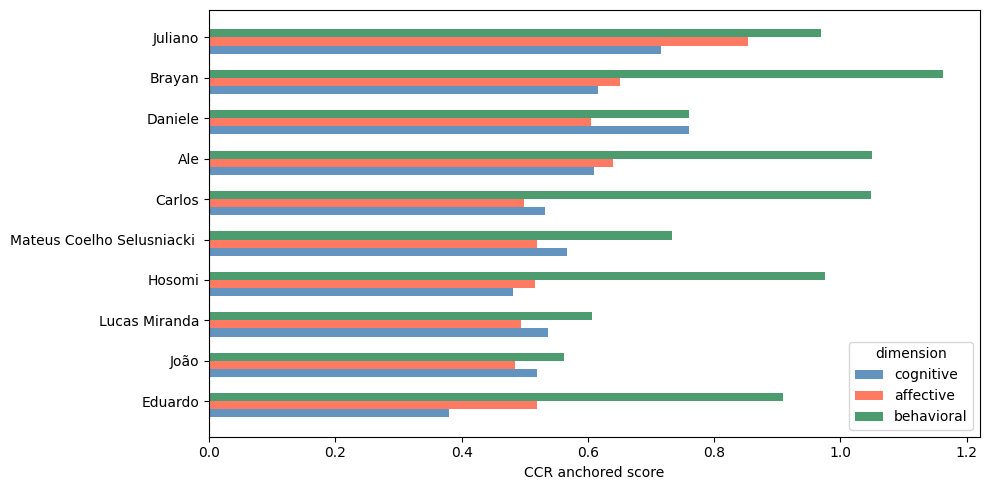

In [134]:
score_cols = [f"ccr_{d}" for d in dimensions] + ["ccr_anchored"]
labels     = dimensions

test_sorted = test.sort_values("ccr_anchored")
names       = test_sorted["Name"]

x     = np.arange(len(names))
width = 0.2
fig, ax = plt.subplots(figsize=(10, len(names) * 0.5))

colors = ["steelblue", "tomato", "seagreen", "gray"]

for i, (col, label, color) in enumerate(zip(score_cols, labels, colors)):
    offset = (i - len(score_cols)/2 + 0.5) * width
    ax.barh(x + offset, test_sorted[col], width, label=label, color=color, alpha=0.85)

ax.set_yticks(x)
ax.set_yticklabels(names)
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("CCR anchored score")
ax.legend(title="dimension")
plt.tight_layout()
plt.show()

What if we don't have inverted items?

In [135]:
aias_short = [
    "Learning to understand all of the special functions associated with an AI technique/product makes me anxious.",
    "I am afraid that an AI technique/product may make us dependent.",
    "I find humanoid AI techniques/products (e.g. humanoid robots) scary.",
    "I am afraid that an AI technique/product may be misused."
]

# simple negation
aias_short_negation = [
    "Learning to understand all of the special functions associated with an AI technique/product does not make me anxious at all.",
    "I am not afraid in the slightest that an AI technique/product may make us dependent.",
    "I do not find humanoid AI techniques/products (e.g. humanoid robots) scary whatsoever.",
    "I am not at all afraid that an AI technique/product may be misused."
]

# LLM-generated semantic opposites
aias_short_positive = [
    "Learning to understand all of the special functions associated with an AI technique/product excites and energizes me.",
    "I believe that AI techniques/products will empower us and strengthen our autonomy.",
    "I find humanoid AI techniques/products (e.g. humanoid robots) fascinating and approachable.",
    "I am confident that AI techniques/products will be used responsibly and for the benefit of society."
]

In [136]:
aias_vec = normalize(
    model.encode(aias_short, batch_size=64, convert_to_numpy=True)
    .mean(axis=0).reshape(1, -1)
).flatten()

aias_neg_vec = normalize(
    model.encode(aias_short_negation, batch_size=64, convert_to_numpy=True)
    .mean(axis=0).reshape(1, -1)
).flatten()

aias_opp_vec = normalize(
    model.encode(aias_short_positive, batch_size=64, convert_to_numpy=True)
    .mean(axis=0).reshape(1, -1)
).flatten()

aias_negation_vec = aias_neg_vec - aias_vec
aias_positive_vec = aias_opp_vec - aias_vec

In [137]:
test["ccr_negation"] = ((test_sent_vecs - aias_vec) @ aias_negation_vec) / np.sum(aias_negation_vec**2)
test["ccr_positive"] = ((test_sent_vecs - aias_vec) @ aias_positive_vec) / np.sum(aias_positive_vec**2)
# test["ccr_negation"] = test_sent_vecs @ aias_negation_vec
# test["ccr_positive"] = test_sent_vecs @ aias_positive_vec

print(test[["Name", "ccr_negation", "ccr_positive"]].sort_values("ccr_negation"))

r, p = stats.pearsonr(test["ccr_negation"], test["ccr_positive"])
print(f"\nnegation vs positive: r={r:.3f}, p={p:.4f}")

                         Name  ccr_negation  ccr_positive
6                      Carlos      0.178467      0.371660
9                      Hosomi      0.274940      0.564917
8                     Eduardo      0.308692      0.495542
7                      Brayan      0.325301      0.591572
1               Lucas Miranda      0.338685      0.502604
0  Mateus Coelho Selusniacki       0.344582      0.524341
4                         Ale      0.355248      0.607038
3                     Daniele      0.402518      0.728656
2                        João      0.501463      0.590524
5                     Juliano      0.524882      0.981247

negation vs positive: r=0.799, p=0.0055


Correlational anchored vectors

In [143]:
X = model.encode(congress_ratings["text"].tolist())
y = (congress_ratings["EMI_score"]).astype(int)

In [144]:
pls = PLSRegression(n_components=1)
pls.fit(X, y)
cav = pls.x_weights_[:, 0]

train_scores = X @ cav
if np.corrcoef(train_scores, y)[0,1] < 0:
    cav = -cav

In [145]:
tweet_ratings["cav_score"] = normalize(model.encode(
    tweet_ratings["text"],
    batch_size=64,
    convert_to_numpy=True
)) @ cav

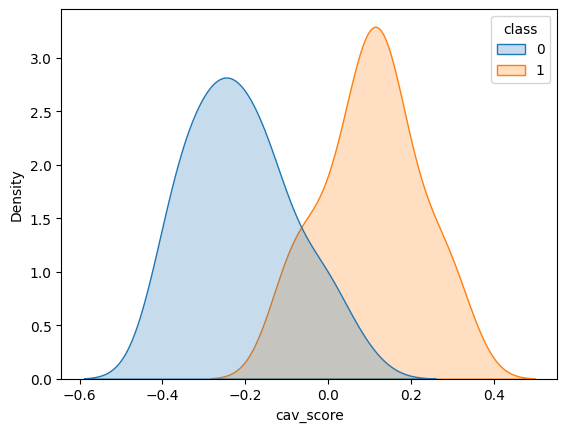

In [146]:
sns.kdeplot(
    data=tweet_ratings,
    x="cav_score",
    hue="class",
    fill=True,
    common_norm=False
)

plt.show()